In [1]:
print('Welcome')

Welcome


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv(r"C:\Users\20122\Downloads\VideoGamesProject-main\VideoGamesProject-main\VideoGamesSales.csv")

# df=df[df.duplicated()]
df=df.drop_duplicates()
df["Region"]=df["Region"].fillna("North")
df["Publisher"]=df["Publisher"].fillna("Nintendo")
df["NA_Sales"]=df["NA_Sales"].replace('[$]','',regex=True)
df["NA_Sales"]=pd.to_numeric(df["NA_Sales"],errors='coerce')
Average_Sales=df["NA_Sales"].mean()
Average_Sales=int(Average_Sales)
df["Country"]=df["Country"].replace({'United States':'USA'})
df["Country"]=df["Country"].replace({'united states':'USA'})
df=df.rename(columns={'NA_Sales':'National Sales','Global_Sales':'Global Sales','NA_Profit':'National Profit','Global_Profit':'Global Profit'})
sales_cap=df['National Sales'].quantile(0.95)
df['National Sales']=np.where(df['National Sales']>sales_cap,sales_cap,df['National Sales'])
df



,Rank,Name,Platform,Year,Month,Genre,Publisher,Country,City,State,Region,National Sales,Global Sales,National Profit,Global Profit
0,1,Wii Sports,Wii,2010,Jan,Sports,Nintendo,USA,Fairfield,California,West,2.07,82.74,12.447,24.822
1,2,Super Mario Bros.,NES,2010,Feb,Platform,Nintendo,USA,Edmonds,Washington,West,2.07,40.24,8.724,12.072
2,3,Mario Kart Wii,Wii,2010,Mar,Racing,Nintendo,USA,Louisville,Kentucky,South,2.07,35.82,4.755,10.746
3,4,Wii Sports Resort,Wii,2010,Apr,Sports,Nintendo,USA,Round Rock,Texas,Central,2.07,33.00,4.725,9.900
4,5,Pokemon Red/Pokemon Blue,GB,2010,May,Role-Playing,Nintendo,USA,Nashville,Tennessee,South,2.07,31.37,3.381,9.411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5904,5890,Crazy Taxi: Catch a Ride,GBA,2017,Sep,Racing,THQ,Australia,Sydney,New South Wales,West,0.21,0.30,0.063,0.090
5905,5891,MySims Party,DS,2017,Oct,Simulation,Electronic Arts,Australia,Sydney,New South Wales,West,0.15,0.30,0.045,0.090
5906,5892,Harry Potter and the Order of the Phoenix,X360,2017,Nov,Action,Electronic Arts,Australia,Sydney,New South Wales,West,0.24,0.30,0.072,0.090
5907,5893,Skylanders: SuperChargers,PS4,2017,Dec,Action,Activision,Australia,Sydney,New South Wales,West,0.17,0.30,0.051,0.090


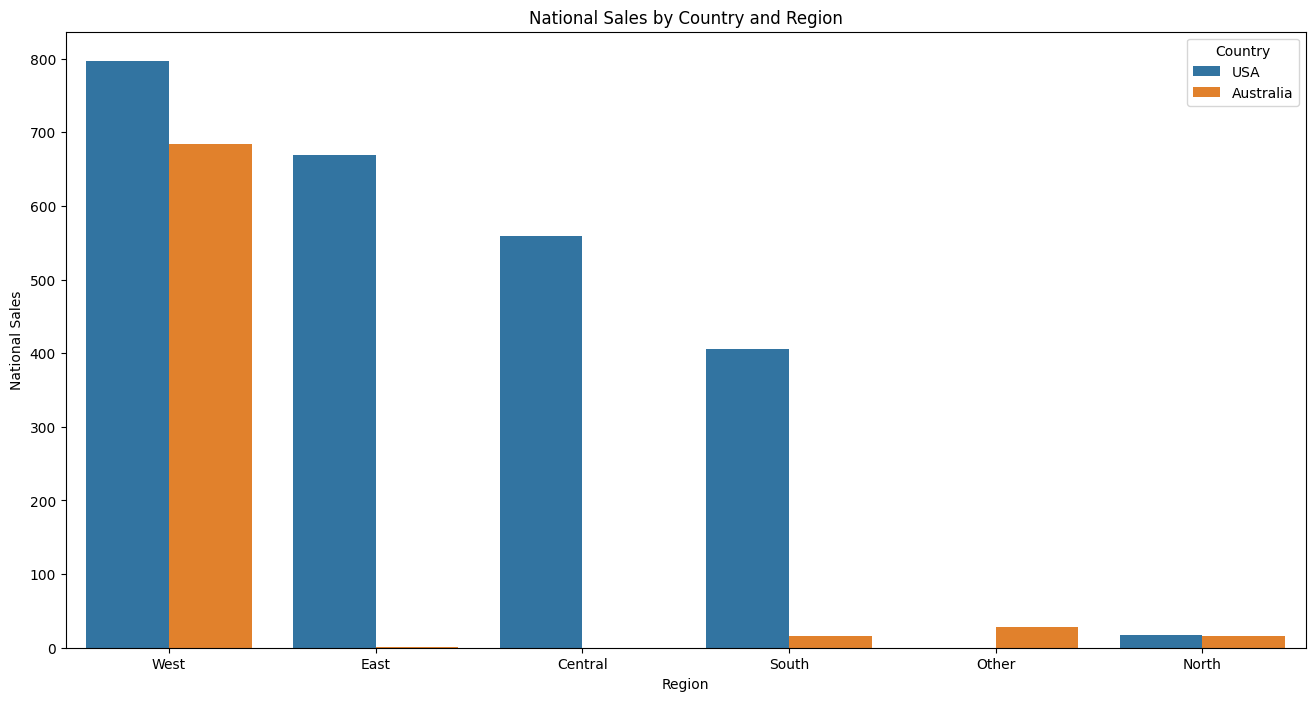

In [9]:

National_Sales=df.groupby(['Region','Country'])['National Sales'].sum().reset_index().sort_values(by='National Sales',ascending=False)
National_Sales
plt.figure(figsize=(16,8))
sns.barplot(data=National_Sales,x='Region',y='National Sales',hue='Country')
plt.title('National Sales by Country and Region')
plt.xlabel('Region')
plt.ylabel('National Sales')
plt.show()

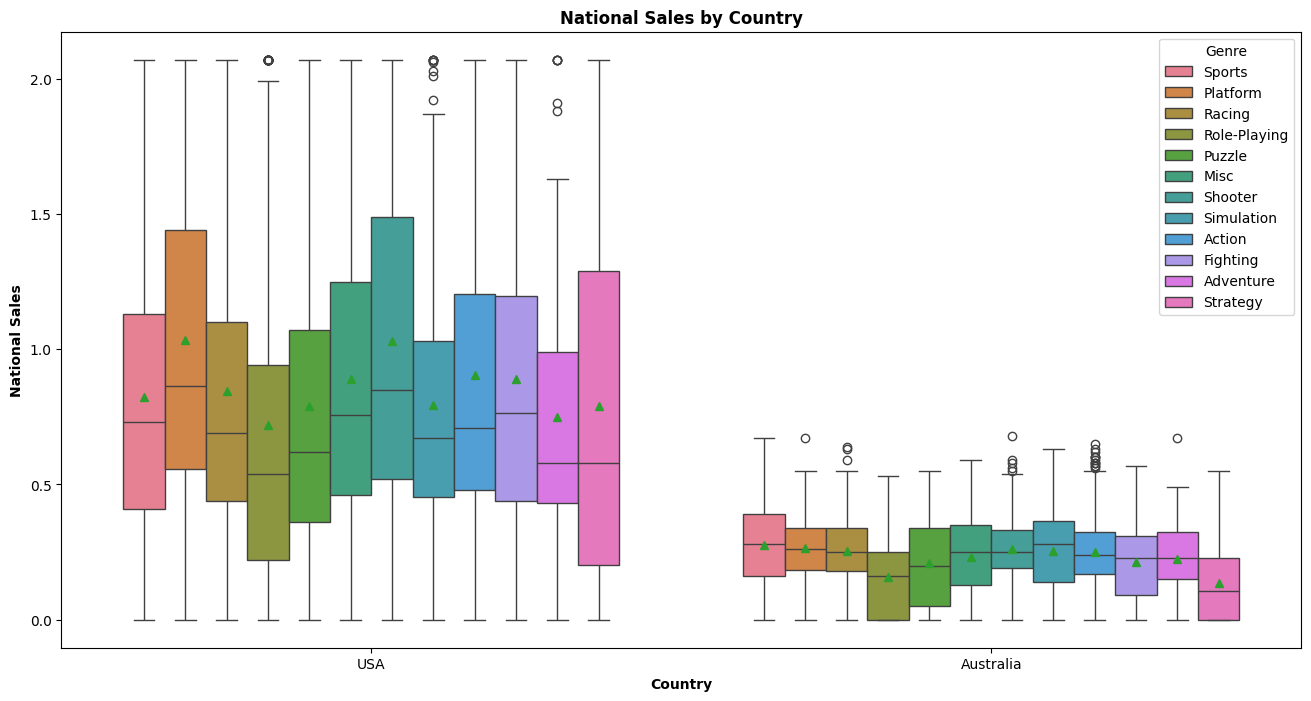

In [13]:
plt.figure(figsize=(16,8))
sns.boxplot(x='Country',y='National Sales',data=df,showmeans=True, hue='Genre')
plt.title('National Sales by Country',fontweight='bold')
plt.xlabel('Country',fontweight='bold')
plt.ylabel('National Sales',fontweight='bold')
plt.show()

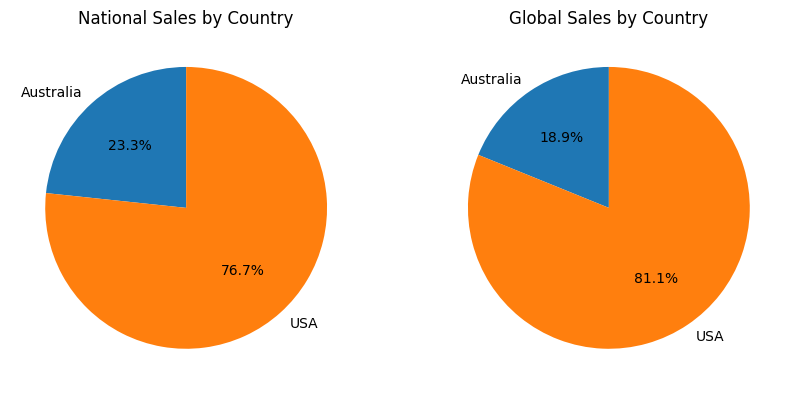

In [22]:
Sales=df.groupby(['Country'])[['National Sales','Global Sales']].sum().reset_index()
Sales
Country=Sales['Country']
National_Sales=Sales['National Sales']
Global_Sales=Sales['Global Sales']
fig,axis=plt.subplots(1,2,figsize=(10,7))
axis[0].pie(National_Sales,labels=Country,autopct='%1.1f%%',startangle= 90)
axis[0].set_title('National Sales by Country')
axis[1].pie(Global_Sales,labels=Country,autopct='%1.1f%%',startangle= 90)
axis[1].set_title('Global Sales by Country')
plt.show()

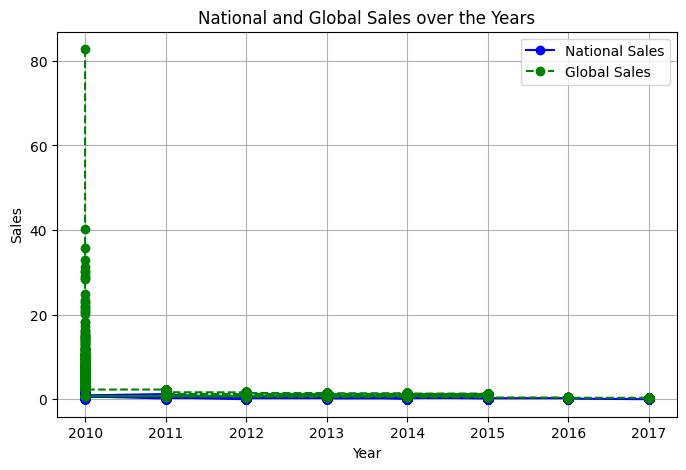

In [30]:
plt.figure(figsize=(8,5))
plt.plot(df['Year'],df['National Sales'],marker='o',linestyle='-',color='b',label='National Sales')
plt.plot(df['Year'],df['Global Sales'],marker='o',linestyle='--',color='g',label='Global Sales')
plt.title('National and Global Sales over the Years')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()